In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 
%matplotlib inline

In [2]:
from IPython import display
display.set_matplotlib_formats('svg')

C:\Users\aravi\anaconda3\envs\aravind\lib\site-packages\ipykernel_launcher.py:2: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  


In [3]:
from download import download

In [4]:
import datetime
import requests
coindeskURL = 'https://api.coindesk.com/v1/bpi/historical/close.json?'

#its a bitcoin dataset 


start = datetime.date(2017, 1 ,1)
end = datetime.date(2020, 7, 2)

url = f'{coindeskURL}start={start:%Y-%m-%d}&end={end:%Y-%m-%d}'

result = requests.get(url)
#result.content

In [5]:
url

'https://api.coindesk.com/v1/bpi/historical/close.json?start=2017-01-01&end=2020-07-02'

In [6]:
summa = pd.read_json(result.content)

In [7]:
summa.head()

,bpi,disclaimer,time
2017-01-01,997.6888,This data was produced from the CoinDesk Bitco...,NaN
2017-01-02,1018.0500,This data was produced from the CoinDesk Bitco...,NaN
2017-01-03,1030.8175,This data was produced from the CoinDesk Bitco...,NaN
2017-01-04,1129.8700,This data was produced from the CoinDesk Bitco...,NaN
2017-01-05,1005.8150,This data was produced from the CoinDesk Bitco...,NaN


In [8]:
data = pd.read_json(result.content).iloc[:-2,:1]

In [9]:
data


# Bitcoin dataset.

,bpi
2017-01-01,997.6888
2017-01-02,1018.0500
2017-01-03,1030.8175
2017-01-04,1129.8700
2017-01-05,1005.8150
...,...
2020-06-28,8991.5000
2020-06-29,9096.1500
2020-06-30,9144.3850
2020-07-01,9153.9500


In [10]:
data.index.name = 'data'
data.index = pd.to_datetime(data.index)
data.head()

,bpi
data,
2017-01-01,997.6888
2017-01-02,1018.0500
2017-01-03,1030.8175
2017-01-04,1129.8700
2017-01-05,1005.8150


In [11]:
data.shape

(1279, 1)

<Figure size 720x576 with 0 Axes>

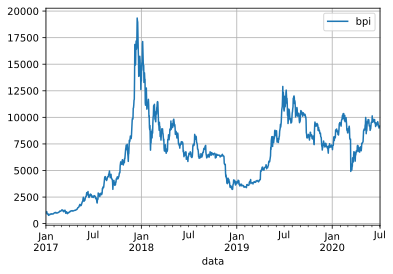

In [12]:
plt.figure(figsize = (10,8))
data.plot()
plt.grid()
plt.show();

## Python Functions

####  Resample Function
* Here the data is in daily basics. so, we can convert this in montly, weekly, daily, seconds for better visualization.
* For that we use the resample technique. Inside the function we need to give attribut how long we need to resample for that, I have mentioned many things below-
* D - Calendar Day
* B - Business Day
* W - Weekly Day
* M - Month
* Q - Quarter
* A - Yearend
* H - Hours
* T - Time
* S - Seconds

In [13]:
data.resample('Q').mean() # it resampled in quarterly basics.

,bpi
data,
2017-03-31,1034.169242
2017-06-30,1919.658520
2017-09-30,3506.611449
2017-12-31,9413.347972
2018-03-31,10468.423818
2018-06-30,7747.165877
2018-09-30,6798.307918
2018-12-31,5169.904503
2019-03-31,3781.639959


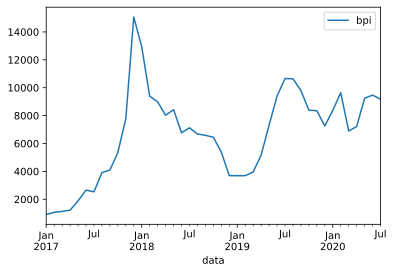

In [14]:
data.resample('M').mean().plot();

# I am doing for montly basics......

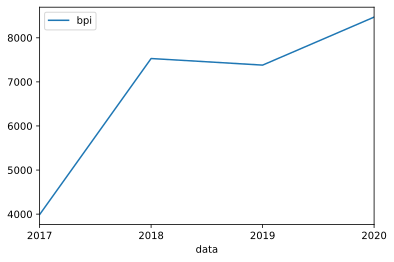

In [20]:
data.resample('Y ').mean().plot();

In [21]:
data[:5]

,bpi
data,
2017-01-01,997.6888
2017-01-02,1018.0500
2017-01-03,1030.8175
2017-01-04,1129.8700
2017-01-05,1005.8150


#### Diff Function
* Mostly all data follows the trend as well as non-trend also.
* Our Ultimate aim to DeTrend the data for better model. 
* The best idea to detrend the data is we minus the current value with pervious value.
* For That we have a very handy function in python, That helps to do the DeTrend Process Easily.


> It Simple words it will subtract the current term and previous term 
>> By Default the period is 1

In [37]:
data[:5]

,bpi
data,
2017-01-01,997.6888
2017-01-02,1018.0500
2017-01-03,1030.8175
2017-01-04,1129.8700
2017-01-05,1005.8150


In [22]:
data[:5].diff() # Here the diff

,bpi
data,
2017-01-01,NaN
2017-01-02,20.3612
2017-01-03,12.7675
2017-01-04,99.0525
2017-01-05,-124.0550


In [23]:
data[:5].diff(2) # Instead of giving one, we will give 2. 2 means it minus previous 2 ones. 

,bpi
data,
2017-01-01,NaN
2017-01-02,NaN
2017-01-03,33.1287
2017-01-04,111.8200
2017-01-05,-25.0025


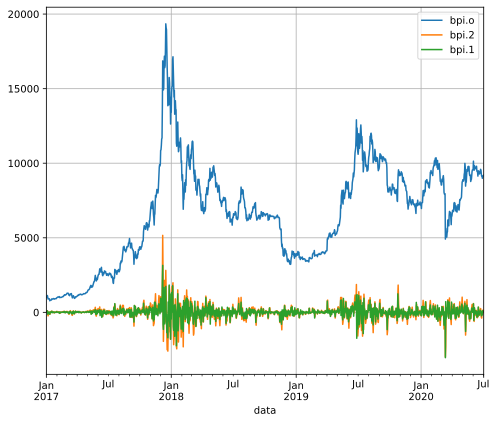

In [31]:
#plt.figure(figsize = (20,8))
pd.concat([data['bpi'], data['bpi'].diff(2), data['bpi'].diff()], axis = 1).plot(figsize = (7, 6));
plt.legend(['bpi.o', 'bpi.2', 'bpi.1'])
plt.grid()
plt.tight_layout();


# Here we deTrend the value 
# And we make our data stationary. 

#### Shift Function
* It shift the value to next one. 
* See below to understand clearly


In [32]:
data.iloc[:5]

,bpi
data,
2017-01-01,997.6888
2017-01-02,1018.0500
2017-01-03,1030.8175
2017-01-04,1129.8700
2017-01-05,1005.8150


In [33]:
data.iloc[:5].shift(1)

,bpi
data,
2017-01-01,NaN
2017-01-02,997.6888
2017-01-03,1018.0500
2017-01-04,1030.8175
2017-01-05,1129.8700


In [34]:
data.iloc[:5].shift(2)

,bpi
data,
2017-01-01,NaN
2017-01-02,NaN
2017-01-03,997.6888
2017-01-04,1018.0500
2017-01-05,1030.8175


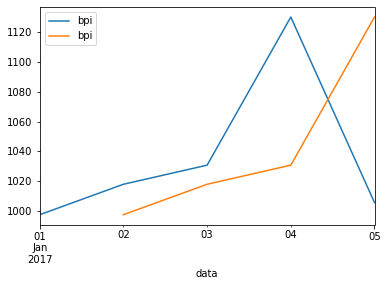

In [46]:
pd.concat([data.iloc[:5], data.iloc[:5].shift(1)], axis = 1).plot(figsize = (7, 6));

In [47]:
data.iloc[:5].tshift(1) # it helps to shift the index.

# T Shift is Time Shift, helps to manipulate the index 

C:\Users\aravi\anaconda3\envs\tensflow\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: tshift is deprecated and will be removed in a future version. Please use shift instead.
  """Entry point for launching an IPython kernel.


,bpi
data,
2017-01-02,997.6888
2017-01-03,1018.0500
2017-01-04,1030.8175
2017-01-05,1129.8700
2017-01-06,1005.8150


In [48]:
data.iloc[:5].tshift(2)

C:\Users\aravi\anaconda3\envs\tensflow\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: tshift is deprecated and will be removed in a future version. Please use shift instead.
  """Entry point for launching an IPython kernel.


,bpi
data,
2017-01-03,997.6888
2017-01-04,1018.0500
2017-01-05,1030.8175
2017-01-06,1129.8700
2017-01-07,1005.8150


In [49]:
data.iloc[:5].shift(4)

,bpi
data,
2017-01-01,NaN
2017-01-02,NaN
2017-01-03,NaN
2017-01-04,NaN
2017-01-05,997.6888


C:\Users\aravi\anaconda3\envs\aravind\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: tshift is deprecated and will be removed in a future version. Please use shift instead.
  """Entry point for launching an IPython kernel.


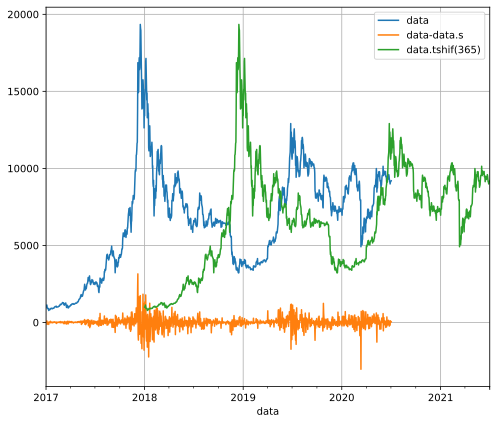

In [37]:
pd.concat([data, data-data.shift(), data.tshift(365)], axis=  1 ).plot(figsize = (7, 6))
plt.legend(['data', 'data-data.s', 'data.tshif(365)'])
plt.grid()
plt.tight_layout()

we just changed a index of next year 

#### Rolling Function
* When to want to calculate the average of last 1 month or last 10 days or last 1 year.
* It will help to do that. 

In [38]:
data.rolling(window = 10).mean() # It will take the last 10 and make average or whatever you want. 

,bpi
data,
2017-01-01,NaN
2017-01-02,NaN
2017-01-03,NaN
2017-01-04,NaN
2017-01-05,NaN
...,...
2020-06-28,9306.16867
2020-06-29,9288.16867
2020-06-30,9271.40667


<AxesSubplot:xlabel='data'>

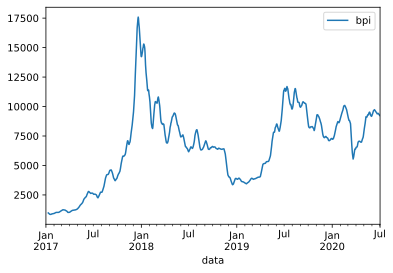

In [40]:
data.rolling(window = 10).mean().plot()

# In simple words I am taking last ten days and averaging it and ploting it 

<AxesSubplot:xlabel='data'>

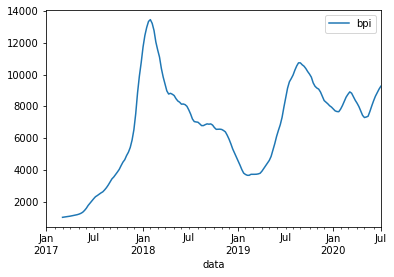

In [52]:
data.resample('W').mean().rolling(window = 10).mean().plot()

<AxesSubplot:xlabel='data'>

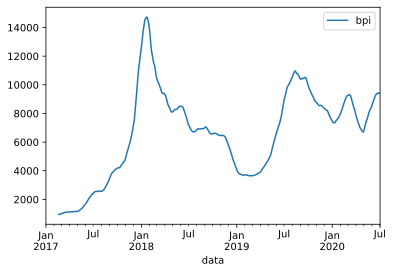

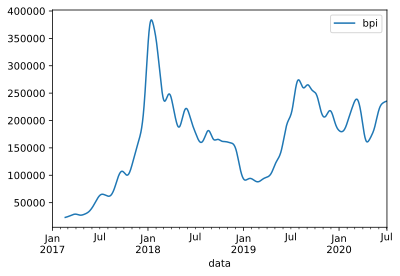

In [41]:
data.rolling(window = 50).mean().plot()
data.rolling(window = 50, win_type = 'gaussian').sum(std = 10).plot()

<AxesSubplot:xlabel='data'>

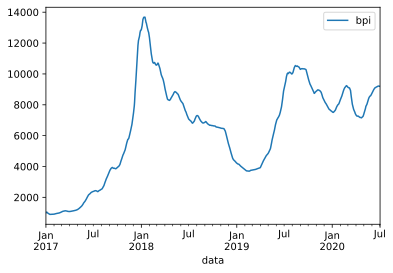

In [42]:
data.ewm(span = 50).mean().plot() # window or span both are same

# ewm is exponential moving average 

<AxesSubplot:xlabel='data'>

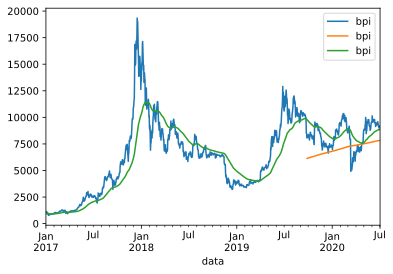

In [43]:
pd.concat([data, data.rolling(window = 1000).mean(),  data.ewm(span = 100).mean()], axis =1).plot()

#### Groupy 
* Sometimes we want to analyze only days or week or only year. 
* Groupy is usefull to do this kind of things. 

In [44]:
data.groupby(data.index.dayofweek).mean() # Here we are just grouping the days

,bpi
data,
0,6612.779266
1,6612.821919
2,6615.719704
3,6595.242466
4,6621.517746
5,6636.877807
6,6588.415989


In [45]:
data.groupby(data.index.month).mean()

,bpi
data,
1,6474.960095
2,5979.032653
3,5241.117152
4,5408.169478
5,6715.698325
6,7074.233533
7,6820.423568
8,7077.441969
9,6825.175222


In [46]:
data.groupby(data.index.year).mean()

,bpi
data,
2017,3990.138147
2018,7529.385702
2019,7379.960562
2020,8468.953262


#### Cumulative sum Function
* It support only sum function

In [47]:
data[:5]

,bpi
data,
2017-01-01,997.6888
2017-01-02,1018.0500
2017-01-03,1030.8175
2017-01-04,1129.8700
2017-01-05,1005.8150


In [48]:
data[:5].cumsum()

,bpi
data,
2017-01-01,997.6888
2017-01-02,2015.7388
2017-01-03,3046.5563
2017-01-04,4176.4263
2017-01-05,5182.2413


#### Percentage Change
* It is very helpfull to find the percentage of each values compare to previous one.
* we can understand, how much percentage the value is changing for each row. 

In [64]:
data[:5].pct_change()

,bpi
data,
2017-01-01,NaN
2017-01-02,0.020408
2017-01-03,0.012541
2017-01-04,0.096091
2017-01-05,-0.109796


#### Expanding
* Same like cummualitve function but here we can use mean, mode anything you want. 

In [49]:
data[:5].expanding().sum()

,bpi
data,
2017-01-01,997.6888
2017-01-02,2015.7388
2017-01-03,3046.5563
2017-01-04,4176.4263
2017-01-05,5182.2413


In [50]:
data[:5].expanding().sum().mode()

,bpi
0,997.6888
1,2015.7388
2,3046.5563
3,4176.4263
4,5182.2413
